# Series와 Broadcasting
> for 문 없이 시리즈의 모든 값들을 대상으로 연산을 수행하는 기술을 브로드캐스팅이라고 함.

### 용어 리마인드
- 0차원 배열 (스칼라, Scalar) ex) 12  *cell값*
- 1차원 배열 (벡터, Vector) ex) [10,20,30] *Series*
- 2차원 배열 (행렬, Metrix) ex) [[10,20,30],[40,50,60]] *DataFrame*

In [1]:
# Series 데이터 만들기
import pandas as pd
datas= pd.Series([10,20,30,40,50])
datas

0    10
1    20
2    30
3    40
4    50
dtype: int64

In [3]:
#벡터(시리즈) + 벡터(시리즈)
datas + datas #각 요소끼리 덧셈

0     20
1     40
2     60
3     80
4    100
dtype: int64

In [4]:
#벡터 - 벡터 연산
datas - datas

0    0
1    0
2    0
3    0
4    0
dtype: int64

In [5]:
# 벡터 + 스칼라 [시리즈 + 값 ] : 반복문을 사용하지 않아도 요소마다 값이 더해짐
datas + 3 #각 요소마다 3이 더해짐 [이를 브로드캐스팅 이라고 부름]

0    13
1    23
2    33
3    43
4    53
dtype: int64

In [6]:
# 벡터 * 스칼라
datas * 4

0     40
1     80
2    120
3    160
4    200
dtype: int64

In [7]:
# 벡터 > 스칼라 [각 요소마다 비교연산 수행 ]
datas > 35

0    False
1    False
2    False
3     True
4     True
dtype: bool

In [9]:
# 개수가 다른 벡터끼리 연산하면?
datas + pd.Series([3,4,5])

0    13.0
1    24.0
2    35.0
3     NaN
4     NaN
dtype: float64

# 데이터분석에 많이 사용되는 '표준편차' 계산해보기
> **표준편차** : 데이터들이 평균에 비해 얼마나 편차가 있는지를 알수 있는 값(분산의 제곱근 값)

학생들간의 성적 편차를 통해 그 학급의 학습효과를 측정할 수 있음.   
평균으로는 정확한 그 학급의 학습효과를 측정되지 않을 수 있음. **평균의 함정** 조심.    
[한두명의 학생이 매우 고득점이고 나머지 학생들이 모두 낮아도 평균이 비교적 높게 나올 수 있음]

In [10]:
# 학생들의 파이썬 성적 데이터 리스트
score_list=[78,60,80,69,95,92,84,35,55,100]
score_list

[78, 60, 80, 69, 95, 92, 84, 35, 55, 100]

In [11]:
# 데이터 분석을 위하여 판다스의 시리즈로 만들기
import pandas as pd
scores= pd.Series(score_list)
scores

0     78
1     60
2     80
3     69
4     95
5     92
6     84
7     35
8     55
9    100
dtype: int64

In [12]:
# 분산을 구하려면 평균부터 계산
score_mean= scores.mean()
print('평균:', score_mean)

평균: 74.8


In [13]:
# 각 학생들의 점수가 평균과 얼마나 차이가 나는지 확인 ( 편차 )
deviations= scores - score_mean #벡터 - 스칼라
deviations

0     3.2
1   -14.8
2     5.2
3    -5.8
4    20.2
5    17.2
6     9.2
7   -39.8
8   -19.8
9    25.2
dtype: float64

In [14]:
# 학생 점수들이 평균에 비해 얼마나 벌어져 있는지(분산된 정도)를 계산하기
# 편차의 평균을 위해 단순히 편차들을 더하면..0에 가까워짐. 지수표현..인식!!
print( deviations.sum() )

2.842170943040401e-14


In [17]:
# 분산의 정도를 수치화 하기 위해..각 편차들을 제곱하여 덧셈한후 개수로 나누기
variance= (deviations**2).sum() / deviations.shape[0]
print('분산:', variance)

분산: 368.96000000000004


In [18]:
# 학생들간의 점수차이가 368.96 정도 난다는 것이 이상함..단위가 너무 큼. 왜? 제곱했으니..
# 그래서 등장한 '표준편차' standard deviation

# 표준편차 = 루트(분산)
std= variance ** (1/2)
print('표준편차:', std)

표준편차: 19.20833152566875


In [19]:
# 데이터분석에서 표준편차를 구하는 작업은 매우 빈번하게 사용됨.
# 매번 위 코드들을 직접 작성하는 것 짜증.
# 판다스 안에 이미 표준편차를 구해주는 기능함수가 존재함.
print( scores.std() )

20.247359224243432


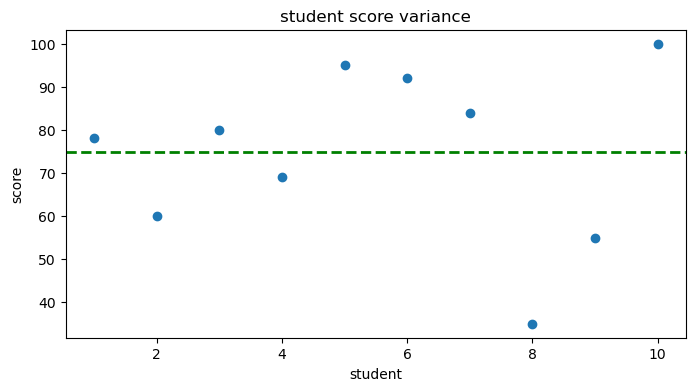

In [21]:
# 이 결과를 시각적으로 확인하기 위해 그래프 사용
import matplotlib.pyplot as plt
#평균
mean_score= scores.mean()

#x축(학생 번호)
x= scores.index+1 

#그래프 그리기
plt.figure(figsize=(8,4))
plt.scatter(x, scores)
plt.axhline(mean_score, color='green', linestyle='--', linewidth=2)

plt.title('student score variance')
plt.xlabel('student')
plt.ylabel('score')

plt.show()

(수행과제) 국어, 영어, 수학 과목 중 교육방식의 효과가 좋은(표준편차가 적은~ 어떤 학생이든 비슷한 수준의 성취도를 달성 가능) 교과목 찾기.
[ 이름, 국어, 영어, 수학 ] 점수를 가진 데이터프레임 만들어서 각 교과목의 표준편차 계산 및 비교

In [22]:
students_score_df= pd.read_csv('./data_set/students_score.csv')
students_score_df

,국어,영어,수학
0,92,75,72
1,45,74,90
2,60,77,65
3,98,73,78
4,40,76,80
5,95,74,60
6,55,75,85
7,100,77,70
8,50,74,76
9,90,76,74


In [23]:
#과목별 평균 확인
print('국어평균:', students_score_df['국어'].mean() )
print('영어평균:', students_score_df['영어'].mean() )
print('수학평균:', students_score_df['수학'].mean() )

국어평균: 72.5
영어평균: 75.1
수학평균: 75.0


In [24]:
#학생들간의 편차를 확인 '표준편차' 확인
print('국어 표준편차:', students_score_df['국어'].std() )
print('영어 표준편차:', students_score_df['영어'].std() )
print('수학 표준편차:', students_score_df['수학'].std() )

국어 표준편차: 24.450630530383737
영어 표준편차: 1.3703203194062976
수학 표준편차: 8.94427190999916


C:\Users\mbca\AppData\Local\Temp\ipykernel_15072\1641473892.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


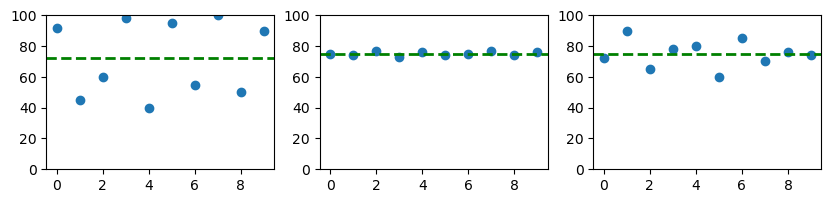

In [27]:
# 교과목의 평균과 분산 정도를 시각화
import matplotlib.pyplot as plt

# 그래프들이 그려질 영역 만들기
fig= plt.figure(figsize=(10, 2))

# 하위 그래프 
axes1 = fig.add_subplot(1, 3, 1) # 1행 3열의 1번째
axes2 = fig.add_subplot(1, 3, 2) # 1행 3열의 2번째
axes3 = fig.add_subplot(1, 3, 3) # 1행 3열의 3번째

# 각 그래프에 데이터 설정
axes1.scatter(students_score_df.index, students_score_df['국어'])
axes1.axhline(students_score_df['국어'].mean(), color='green', linestyle='--', linewidth=2)
axes1.set_ylim(0, 100)

axes2.scatter(students_score_df.index, students_score_df['영어'])
axes2.axhline(students_score_df['영어'].mean(), color='green', linestyle='--', linewidth=2)
axes2.set_ylim(0, 100)

axes3.scatter(students_score_df.index, students_score_df['수학'])
axes3.axhline(students_score_df['수학'].mean(), color='green', linestyle='--', linewidth=2)
axes3.set_ylim(0, 100)

fig.show()

결론.
국어, 영어, 수학 모두 평균수치는 유사함.
국어 일부만 잘하고 대부분의 낮음. 편차가 심함. --> 교육효과 불균형
영어 대부분 고르게 성취 달성 --> 교육 효과 우수
수학 전반적으로 다소 성취 차이 있음 --> 차이를 줄이는 방식을 검토.

(표준편차 사례 과제) 회사추천 프로그램 -(연봉을 중요시할때)

A 회사
직원 수: 30명

B 회사
직원 수: 30명


두 회사 중 연봉기준으로 입사할 경우 더 만족할 만한 회사를 선택하기 위해 연봉데이터를 분석해 보시오.
salary_df= pd.read_csv('./data_set/salary.csv')



수행항목
1. 회사별 연봉 평균 확인
2. 회사별 표준편차 확인 

3. 각 회사의 최저 연봉
4. 각 회사의 최고 연봉
-------------------------------

분석 결과
OO 회사
직원 수: 30명
임원 O명: 억대 연봉 (1억~1억5천)
일반 직원 OO명: 2,600 ~ 3,200

특징
평균 높음 (임원 때문에)
표준편차 매우 큼
“소수만 잘 받는 회사”


OO 회사
직원 수: 30명
연봉 범위: 3,600 ~ 8,000

특징
평균 비교적 낮음 
표준편차 작음
“구성원 전반이 고르게 받는 회사”
----------------------------------------

# 수행과제. 교재 chapter 02~03 읽고 예제 따라하기!!!